
# CORI manuscript figures — clean final notebook

This notebook recreates the manuscript figures **from top to bottom** using the current locked scores and the latest analysis tables.

## Figure order

1. Central Illustration — retinal vascular susceptibility and cancer-related amplification  
2. Figure 1 — clean study cohorts  
3. Figure 2 — held-out CORI risk stratification and clinical enrichment  
4. Figure 3 — CORI versus MMACE  
5. Figure 4 — retinal and CMR biological anchoring  
6. Figure 5 — four-way pathway decomposition and cancer-type heterogeneity  
7. Supplementary figures — center, treatment, representation, calibration, subtype contribution, and event horizons  

All figures use the same restrained manuscript palette and are saved as **PNG, PDF, and SVG**.  
All score-level analyses shown here use the locked **meanpool_pre** CORI/MMACE scores.


In [1]:

# 0. Configuration, imports, and manuscript style

from pathlib import Path
import textwrap
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from lifelines import KaplanMeierFitter
from lifelines.utils import concordance_index
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

ROOT = Path(r"F:\CORI_Final\CORI_JACC_Final\CORI_Submit")

TABLE_DIR = ROOT / "outputs_refactored" / "tables"
ADDITIONAL_DIR = ROOT / "outputs_refactored" / "additional_manuscript_analyses"
FOURWAY_DIR = ROOT / "outputs_refactored" / "four_way_decomposition" / "tables"
SCORES_CSV = ROOT / "outputs_refactored" / "scores" / "locked_scores_all_cohorts.csv"

FIGURE_DIR = ROOT / "outputs_refactored" / "final_manuscript_figures"
SOURCE_DIR = FIGURE_DIR / "source_data"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
SOURCE_DIR.mkdir(parents=True, exist_ok=True)

# Manuscript palette retained from the previous figure notebooks.
NAVY = "#052433"
NAVY_MID = "#10414D"
NAVY_LIGHT = "#DDE6E8"

CORI = "#2C2BFD"
CORI_DARK = "#2331C7"
CORI_MID = "#8285F6"
CORI_LIGHT = "#D9DAFF"

MMACE = "#F08438"
MMACE_DARK = "#C85C16"
MMACE_MID = "#F9AA42"
MMACE_LIGHT = "#FBE2C8"

CORAL = "#DD6C4F"
CORAL_DARK = "#BA393A"
CORAL_MID = "#ED8F88"
CORAL_LIGHT = "#EFDDDB"

GRAY = "#8A8A90"
GRAY_DARK = "#414244"
GRAY_MID = "#B6B0C0"
GRAY_LIGHT = "#EFF0F0"
GRID = "#E0E1E2"
WHITE = "#FFFFFF"
BLACK = "#141D21"

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 9.5,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.labelsize": 9.5,
        "axes.edgecolor": NAVY,
        "axes.linewidth": 0.8,
        "xtick.color": BLACK,
        "ytick.color": BLACK,
        "text.color": BLACK,
        "figure.facecolor": WHITE,
        "axes.facecolor": WHITE,
        "savefig.facecolor": WHITE,
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
    }
)

def require(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return path

def read_csv(path):
    return pd.read_csv(require(path))

def p_text(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "p<0.001"
    return f"p={p:.3f}"

def short_text(value, width=30):
    return "\n".join(textwrap.wrap(str(value), width=width))

def panel_letter(ax, letter, x=-0.10, y=1.06):
    ax.text(
        x, y, letter,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        color=NAVY,
        ha="left",
        va="bottom",
    )

def clean_axes(ax, grid_axis=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.7, alpha=0.8)
        ax.set_axisbelow(True)

def save_figure(fig, stem):
    for extension in ("png", "pdf", "svg"):
        kwargs = {"bbox_inches": "tight"}
        if extension == "png":
            kwargs["dpi"] = 600
        fig.savefig(FIGURE_DIR / f"{stem}.{extension}", **kwargs)
    print("Saved:", FIGURE_DIR / f"{stem}.png")

def add_box(ax, xy, width, height, text, facecolor, edgecolor=NAVY, fontsize=9.5):
    x, y = xy
    box = patches.FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.02,rounding_size=0.025",
        linewidth=1.1,
        edgecolor=edgecolor,
        facecolor=facecolor,
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        color=NAVY,
        fontweight="bold",
    )
    return box

def add_arrow(ax, start, end, color=NAVY_MID, lw=1.4, connectionstyle="arc3"):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=lw,
            shrinkA=2,
            shrinkB=2,
            connectionstyle=connectionstyle,
        ),
    )

# Required latest inputs.
required_files = [
    SCORES_CSV,
    TABLE_DIR / "Table_00_clean_cohort_audit.csv",
    TABLE_DIR / "Table_02_primary_CORI_performance.csv",
    TABLE_DIR / "Table_03_CORI_horizon_performance.csv",
    TABLE_DIR / "Table_05_D2_multivariable_CORI_association.csv",
    TABLE_DIR / "Table_08A_clinical_to_CORI_counts.csv",
    TABLE_DIR / "Table_08B_clinical_to_CORI_event_rates.csv",
    TABLE_DIR / "Table_09_cross_domain_CORI_MMACE.csv",
    TABLE_DIR / "Table_10A_equal_MMACE_to_CORI_counts.csv",
    TABLE_DIR / "Table_10B_equal_MMACE_to_CORI_event_rates.csv",
    TABLE_DIR / "Table_01B_CORI_residualized_MMACE.csv",
    TABLE_DIR / "Table_14E_top10_raw_D2_handcrafted_CORI_correlations.csv",
    TABLE_DIR / "Table_15D_CMR_directional_component_tests.csv",
    TABLE_DIR / "Table_15E_CMR_directional_domain_ACAT.csv",
    FOURWAY_DIR / "Table_04_CORI_fourway_manuscript_summary.csv",
    ADDITIONAL_DIR / "Table_14_CORI_main_cancer_subtypes_D2.csv",
]
for file in required_files:
    require(file)

print("Figure output:", FIGURE_DIR)


Figure output: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\final_manuscript_figures


In [2]:

# 1. Load the current locked scores and latest figure tables

scores = read_csv(SCORES_CSV)
scores["cohort"] = scores["cohort"].astype(str)
scores["eid"] = scores["eid"].astype(str).str.replace(r"\.0$", "", regex=True)

cohort_audit = read_csv(TABLE_DIR / "Table_00_clean_cohort_audit.csv")
primary_performance = read_csv(TABLE_DIR / "Table_02_primary_CORI_performance.csv")
horizon_performance = read_csv(TABLE_DIR / "Table_03_CORI_horizon_performance.csv")
adjusted_cox = read_csv(TABLE_DIR / "Table_05_D2_multivariable_CORI_association.csv")

clinical_counts = read_csv(TABLE_DIR / "Table_08A_clinical_to_CORI_counts.csv")
clinical_rates = read_csv(TABLE_DIR / "Table_08B_clinical_to_CORI_event_rates.csv")

cross_domain = read_csv(TABLE_DIR / "Table_09_cross_domain_CORI_MMACE.csv")
mmace_counts = read_csv(TABLE_DIR / "Table_10A_equal_MMACE_to_CORI_counts.csv")
mmace_rates = read_csv(TABLE_DIR / "Table_10B_equal_MMACE_to_CORI_event_rates.csv")
residual_results = read_csv(TABLE_DIR / "Table_01B_CORI_residualized_MMACE.csv")

handcrafted = read_csv(TABLE_DIR / "Table_14E_top10_raw_D2_handcrafted_CORI_correlations.csv")
cmr_components = read_csv(TABLE_DIR / "Table_15D_CMR_directional_component_tests.csv")
cmr_domains = read_csv(TABLE_DIR / "Table_15E_CMR_directional_domain_ACAT.csv")

fourway = read_csv(FOURWAY_DIR / "Table_04_CORI_fourway_manuscript_summary.csv")
subtypes = read_csv(ADDITIONAL_DIR / "Table_14_CORI_main_cancer_subtypes_D2.csv")

assert len(scores.query("cohort == 'D2'")) == 2249
assert int(scores.query("cohort == 'D2'")["Y_mace"].sum()) == 326
assert len(scores.query("cohort in ['D2', 'D4']")) == 17012

print("D2:", len(scores.query("cohort == 'D2'")), "participants /", int(scores.query("cohort == 'D2'")["Y_mace"].sum()), "events")
print("D2+D4:", len(scores.query("cohort in ['D2', 'D4']")), "participants /", int(scores.query("cohort in ['D2', 'D4']")["Y_mace"].sum()), "events")


D2: 2249 participants / 326 events
D2+D4: 17012 participants / 1787 events


## Central Illustration — retinal vascular susceptibility in cancer

Saved: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\final_manuscript_figures\Central_Illustration_CORI_susceptibility_amplification.png


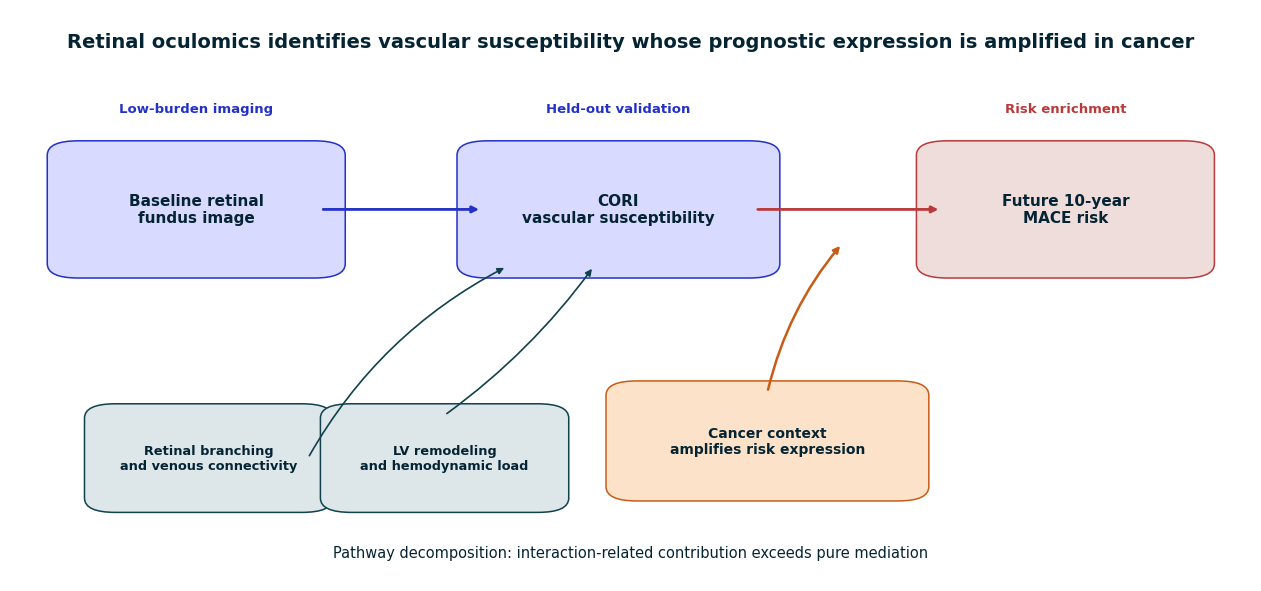

In [3]:

# Central Illustration

fig, ax = plt.subplots(figsize=(12.5, 5.8), layout="constrained")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(
    0.5, 0.96,
    "Retinal oculomics identifies vascular susceptibility whose prognostic expression is amplified in cancer",
    ha="center", va="top", fontsize=14, fontweight="bold", color=NAVY,
)

add_box(ax, (0.05, 0.55), 0.20, 0.20, "Baseline retinal\nfundus image", CORI_LIGHT, CORI_DARK, 11)
add_box(ax, (0.38, 0.55), 0.22, 0.20, "CORI\nvascular susceptibility", CORI_LIGHT, CORI_DARK, 11)
add_box(ax, (0.75, 0.55), 0.20, 0.20, "Future 10-year\nMACE risk", CORAL_LIGHT, CORAL_DARK, 11)

add_arrow(ax, (0.25, 0.65), (0.38, 0.65), CORI_DARK, 2.0)
add_arrow(ax, (0.60, 0.65), (0.75, 0.65), CORAL_DARK, 2.0)

add_box(ax, (0.50, 0.16), 0.22, 0.17, "Cancer context\namplifies risk expression", MMACE_LIGHT, MMACE_DARK, 10)
add_arrow(
    ax, (0.61, 0.33), (0.67, 0.59),
    MMACE_DARK, 1.8, connectionstyle="arc3,rad=-0.12"
)

add_box(ax, (0.08, 0.14), 0.16, 0.15, "Retinal branching\nand venous connectivity", NAVY_LIGHT, NAVY_MID, 9.3)
add_box(ax, (0.27, 0.14), 0.16, 0.15, "LV remodeling\nand hemodynamic load", NAVY_LIGHT, NAVY_MID, 9.3)
add_arrow(ax, (0.24, 0.215), (0.40, 0.55), NAVY_MID, 1.2, connectionstyle="arc3,rad=-0.15")
add_arrow(ax, (0.35, 0.29), (0.47, 0.55), NAVY_MID, 1.2, connectionstyle="arc3,rad=0.08")

ax.text(0.15, 0.82, "Low-burden imaging", ha="center", color=CORI_DARK, fontweight="bold")
ax.text(0.49, 0.82, "Held-out validation", ha="center", color=CORI_DARK, fontweight="bold")
ax.text(0.85, 0.82, "Risk enrichment", ha="center", color=CORAL_DARK, fontweight="bold")

ax.text(
    0.5, 0.05,
    "Pathway decomposition: interaction-related contribution exceeds pure mediation",
    ha="center", va="center", fontsize=10.5, color=NAVY,
)

save_figure(fig, "Central_Illustration_CORI_susceptibility_amplification")
plt.show()


## Figure 1 — clean study design and analytic cohorts

Saved: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\final_manuscript_figures\Figure1_clean_study_design.png


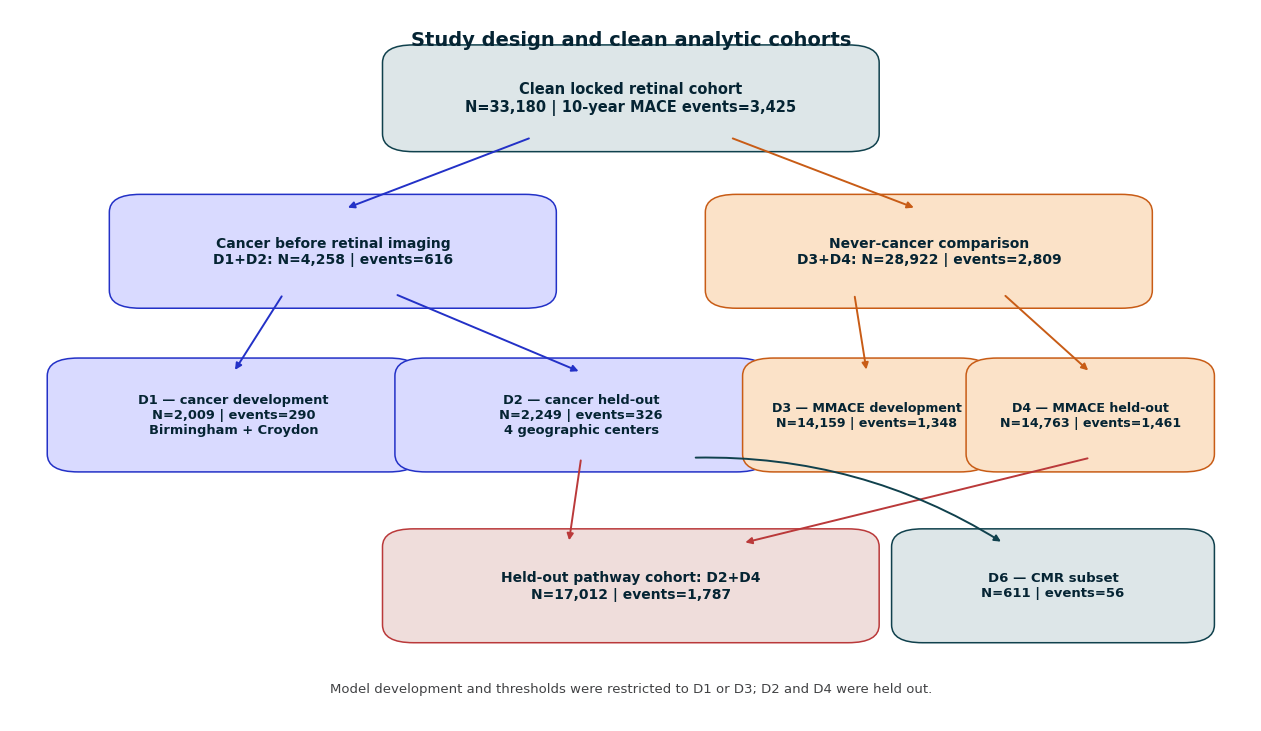

In [4]:

# Figure 1. Clean study design and analytic cohorts

audit = cohort_audit.set_index("cohort")
d1_n, d1_e = int(audit.loc["D1", "N"]), int(audit.loc["D1", "events"])
d2_n, d2_e = int(audit.loc["D2", "N"]), int(audit.loc["D2", "events"])
d3_n, d3_e = int(audit.loc["D3", "N"]), int(audit.loc["D3", "events"])
d4_n, d4_e = int(audit.loc["D4", "N"]), int(audit.loc["D4", "events"])
d6_n, d6_e = int(audit.loc["D6", "N"]), int(audit.loc["D6", "events"])

fig, ax = plt.subplots(figsize=(12.5, 7.2), layout="constrained")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(0.5, 0.97, "Study design and clean analytic cohorts", ha="center", va="top",
        fontsize=14, fontweight="bold", color=NAVY)

total_n = d1_n + d2_n + d3_n + d4_n
total_e = d1_e + d2_e + d3_e + d4_e
add_box(ax, (0.32, 0.82), 0.36, 0.11,
        f"Clean locked retinal cohort\nN={total_n:,} | 10-year MACE events={total_e:,}",
        NAVY_LIGHT, NAVY_MID, 10.5)

add_box(ax, (0.10, 0.60), 0.32, 0.12,
        f"Cancer before retinal imaging\nD1+D2: N={d1_n+d2_n:,} | events={d1_e+d2_e:,}",
        CORI_LIGHT, CORI_DARK, 10)
add_box(ax, (0.58, 0.60), 0.32, 0.12,
        f"Never-cancer comparison\nD3+D4: N={d3_n+d4_n:,} | events={d3_e+d4_e:,}",
        MMACE_LIGHT, MMACE_DARK, 10)

add_arrow(ax, (0.42, 0.82), (0.27, 0.72), CORI_DARK)
add_arrow(ax, (0.58, 0.82), (0.73, 0.72), MMACE_DARK)

add_box(ax, (0.05, 0.37), 0.26, 0.12,
        f"D1 — cancer development\nN={d1_n:,} | events={d1_e:,}\nBirmingham + Croydon",
        CORI_LIGHT, CORI_DARK, 9.4)
add_box(ax, (0.33, 0.37), 0.26, 0.12,
        f"D2 — cancer held-out\nN={d2_n:,} | events={d2_e:,}\n4 geographic centers",
        CORI_LIGHT, CORI_DARK, 9.4)
add_box(ax, (0.61, 0.37), 0.16, 0.12,
        f"D3 — MMACE development\nN={d3_n:,} | events={d3_e:,}",
        MMACE_LIGHT, MMACE_DARK, 9.1)
add_box(ax, (0.79, 0.37), 0.16, 0.12,
        f"D4 — MMACE held-out\nN={d4_n:,} | events={d4_e:,}",
        MMACE_LIGHT, MMACE_DARK, 9.1)

add_arrow(ax, (0.22, 0.60), (0.18, 0.49), CORI_DARK)
add_arrow(ax, (0.31, 0.60), (0.46, 0.49), CORI_DARK)
add_arrow(ax, (0.68, 0.60), (0.69, 0.49), MMACE_DARK)
add_arrow(ax, (0.80, 0.60), (0.87, 0.49), MMACE_DARK)

add_box(ax, (0.32, 0.13), 0.36, 0.12,
        f"Held-out pathway cohort: D2+D4\nN={d2_n+d4_n:,} | events={d2_e+d4_e:,}",
        CORAL_LIGHT, CORAL_DARK, 10)
add_arrow(ax, (0.46, 0.37), (0.45, 0.25), CORAL_DARK)
add_arrow(ax, (0.87, 0.37), (0.59, 0.25), CORAL_DARK)

add_box(ax, (0.73, 0.13), 0.22, 0.12,
        f"D6 — CMR subset\nN={d6_n:,} | events={d6_e:,}",
        NAVY_LIGHT, NAVY_MID, 9.5)
add_arrow(ax, (0.55, 0.37), (0.80, 0.25), NAVY_MID, connectionstyle="arc3,rad=-0.15")

ax.text(
    0.5, 0.04,
    "Model development and thresholds were restricted to D1 or D3; D2 and D4 were held out.",
    ha="center", fontsize=9.5, color=GRAY_DARK,
)

cohort_audit.to_csv(SOURCE_DIR / "Figure1_clean_cohort_audit.csv", index=False)
save_figure(fig, "Figure1_clean_study_design")
plt.show()


## Figure 2 — held-out CORI risk stratification and clinical enrichment

Saved: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\final_manuscript_figures\Figure2_CORI_risk_stratification.png


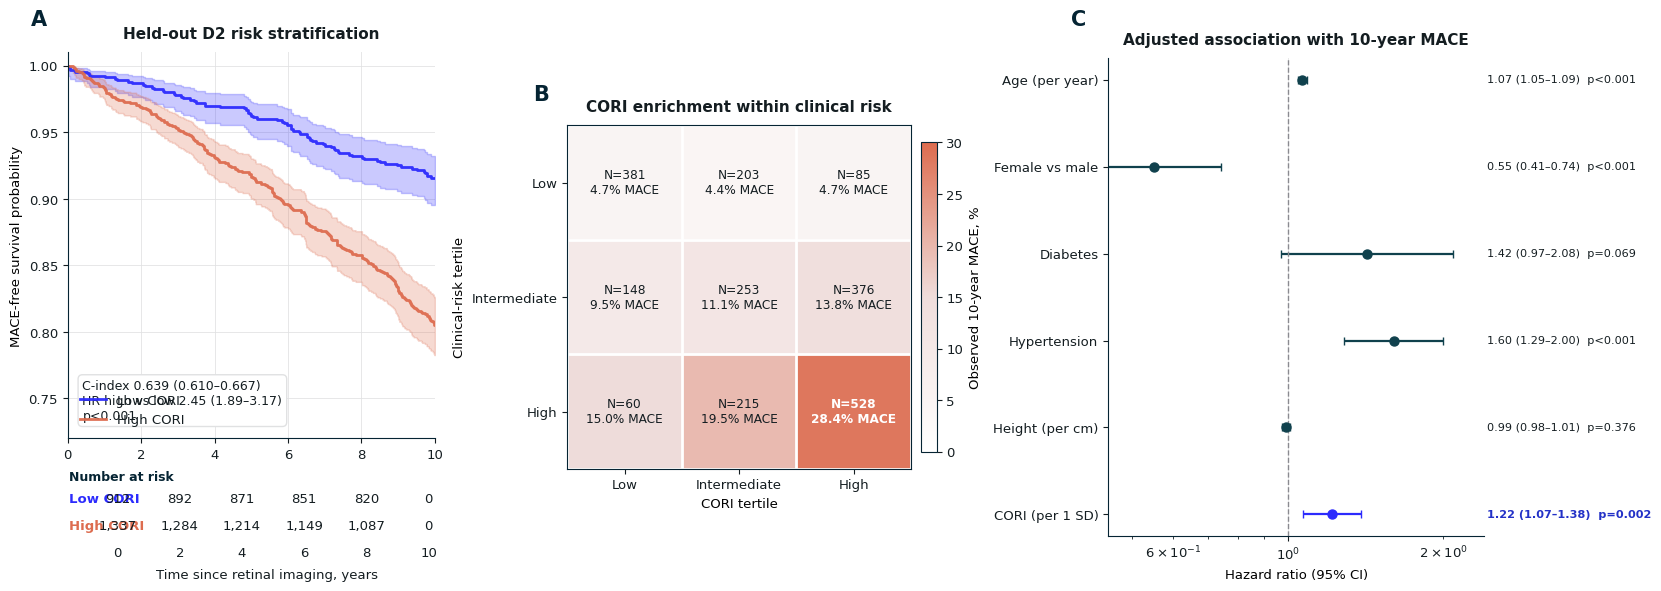

In [5]:

# Figure 2. Held-out CORI risk stratification and clinical enrichment

d1 = scores.query("cohort == 'D1'").copy()
d2 = scores.query("cohort == 'D2'").copy()
cori_threshold = float(d1["CORI_z"].median())

d2["CORI group"] = np.where(d2["CORI_z"] > cori_threshold, "High CORI", "Low CORI")

fig = plt.figure(figsize=(16.5, 5.8), layout="constrained")
gs = fig.add_gridspec(1, 3, width_ratios=[1.35, 1.05, 1.15])

# A. Kaplan-Meier with risk table
sub = gs[0, 0].subgridspec(2, 1, height_ratios=[4.2, 1.0], hspace=0.03)
ax_a = fig.add_subplot(sub[0])
ax_risk = fig.add_subplot(sub[1])

km = KaplanMeierFitter()
group_styles = {
    "Low CORI": (CORI, CORI_LIGHT),
    "High CORI": (CORAL, CORAL_LIGHT),
}
for label in ["Low CORI", "High CORI"]:
    group = d2[d2["CORI group"] == label]
    color, _ = group_styles[label]
    km.fit(group["time_years"], group["Y_mace"], label=label)
    km.plot_survival_function(ax=ax_a, ci_show=True, color=color, linewidth=2.0, alpha=0.95)

ax_a.set_xlim(0, 10)
ax_a.set_ylim(0.72, 1.01)
ax_a.set_xlabel("")
ax_a.set_ylabel("MACE-free survival probability")
ax_a.set_title("Held-out D2 risk stratification", pad=10)
clean_axes(ax_a, "both")
ax_a.legend(frameon=False, loc="lower left")

perf = primary_performance.query("cohort == 'D2 held-out'").iloc[0]
ax_a.text(
    0.04, 0.05,
    f"C-index {perf.C_index:.3f} ({perf.C_low:.3f}–{perf.C_high:.3f})\n"
    f"HR high vs low {perf.HR:.2f} ({perf.HR_low:.2f}–{perf.HR_high:.2f})\n"
    f"{p_text(perf.p)}",
    transform=ax_a.transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.35", facecolor=WHITE, edgecolor=GRID),
)
panel_letter(ax_a, "A")

times = np.array([0, 2, 4, 6, 8, 10])
ax_risk.set_xlim(-1.6, 10.2)
ax_risk.set_ylim(-0.6, 1.6)
ax_risk.axis("off")
ax_risk.text(-1.55, 1.35, "Number at risk", fontweight="bold", color=NAVY, fontsize=9)
for row, label in enumerate(["Low CORI", "High CORI"]):
    group = d2[d2["CORI group"] == label]
    color = group_styles[label][0]
    y = 0.9 - row * 0.65
    ax_risk.text(-1.55, y, label, color=color, fontweight="bold", ha="left", va="center")
    for t in times:
        ax_risk.text(t, y, f"{int((group['time_years'] >= t).sum()):,}", ha="center", va="center")
for t in times:
    ax_risk.text(t, -0.38, str(t), ha="center", va="center")
ax_risk.text(4.8, -0.75, "Time since retinal imaging, years", ha="center", va="top")

# B. Clinical × CORI matrix
ax_b = fig.add_subplot(gs[0, 1])
order = ["Low", "Middle", "High"]
counts = clinical_counts.set_index("Clinical_risk_tertile").loc[order, order]
rates = clinical_rates.set_index("Clinical_risk_tertile").loc[order, order] * 100
cmap = LinearSegmentedColormap.from_list("event_rate", [WHITE, CORAL_LIGHT, CORAL])
image = ax_b.imshow(rates.values, cmap=cmap, vmin=0, vmax=max(30, rates.to_numpy().max()))
for i in range(3):
    for j in range(3):
        value = rates.iloc[i, j]
        color = WHITE if value > 20 else BLACK
        ax_b.text(j, i, f"N={int(counts.iloc[i,j]):,}\n{value:.1f}% MACE",
                  ha="center", va="center", fontsize=8.7, color=color,
                  fontweight="bold" if value > 20 else "normal")
ax_b.set_xticks(range(3), ["Low", "Intermediate", "High"])
ax_b.set_yticks(range(3), ["Low", "Intermediate", "High"])
ax_b.set_xlabel("CORI tertile")
ax_b.set_ylabel("Clinical-risk tertile")
ax_b.set_title("CORI enrichment within clinical risk", pad=10)
for edge in np.arange(-0.5, 3, 1):
    ax_b.axhline(edge, color=WHITE, linewidth=2)
    ax_b.axvline(edge, color=WHITE, linewidth=2)
colorbar = fig.colorbar(image, ax=ax_b, fraction=0.045, pad=0.03)
colorbar.set_label("Observed 10-year MACE, %")
panel_letter(ax_b, "B")

# C. Adjusted Cox forest
ax_c = fig.add_subplot(gs[0, 2])
term_map = {
    "CORI_z": "CORI (per 1 SD)",
    "age": "Age (per year)",
    "female": "Female vs male",
    "Diabetes": "Diabetes",
    "HTN": "Hypertension",
    "height": "Height (per cm)",
}
forest = adjusted_cox[adjusted_cox["term"].isin(term_map)].copy()
forest["label"] = forest["term"].map(term_map)
forest["order"] = forest["term"].map(
    {"age": 0, "female": 1, "Diabetes": 2, "HTN": 3, "height": 4, "CORI_z": 5}
)
forest = forest.sort_values("order", ascending=False)
y = np.arange(len(forest))
colors = [CORI if term == "CORI_z" else NAVY_MID for term in forest["term"]]
for yi, row in enumerate(forest.itertuples()):
    color = CORI if row.term == "CORI_z" else NAVY_MID
    ax_c.errorbar(
        row.HR, yi,
        xerr=[[row.HR - row.HR_low], [row.HR_high - row.HR]],
        fmt="none", ecolor=color, elinewidth=1.6, capsize=3,
    )
    ax_c.scatter(row.HR, yi, s=42, color=color, zorder=3)
ax_c.axvline(1, color=GRAY, linestyle="--", linewidth=1)
ax_c.set_xscale("log")
ax_c.set_xlim(0.45, 2.4)
ax_c.set_yticks(y, forest["label"])
ax_c.set_xlabel("Hazard ratio (95% CI)")
ax_c.set_title("Adjusted association with 10-year MACE", pad=10)
clean_axes(ax_c, "x")
for yi, row in enumerate(forest.itertuples()):
    ax_c.text(
        2.43, yi,
        f"{row.HR:.2f} ({row.HR_low:.2f}–{row.HR_high:.2f})  {p_text(row.p)}",
        ha="left", va="center", fontsize=8.1, clip_on=False,
        color=CORI_DARK if row.term == "CORI_z" else BLACK,
        fontweight="bold" if row.term == "CORI_z" else "normal",
    )
panel_letter(ax_c, "C")

clinical_counts.to_csv(SOURCE_DIR / "Figure2_clinical_CORI_counts.csv", index=False)
clinical_rates.to_csv(SOURCE_DIR / "Figure2_clinical_CORI_event_rates.csv", index=False)
forest.to_csv(SOURCE_DIR / "Figure2_adjusted_forest.csv", index=False)

save_figure(fig, "Figure2_CORI_risk_stratification")
plt.show()


## Figure 3 — CORI versus generic retinal MACE models

Saved: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\final_manuscript_figures\Figure3_CORI_vs_MMACE.png


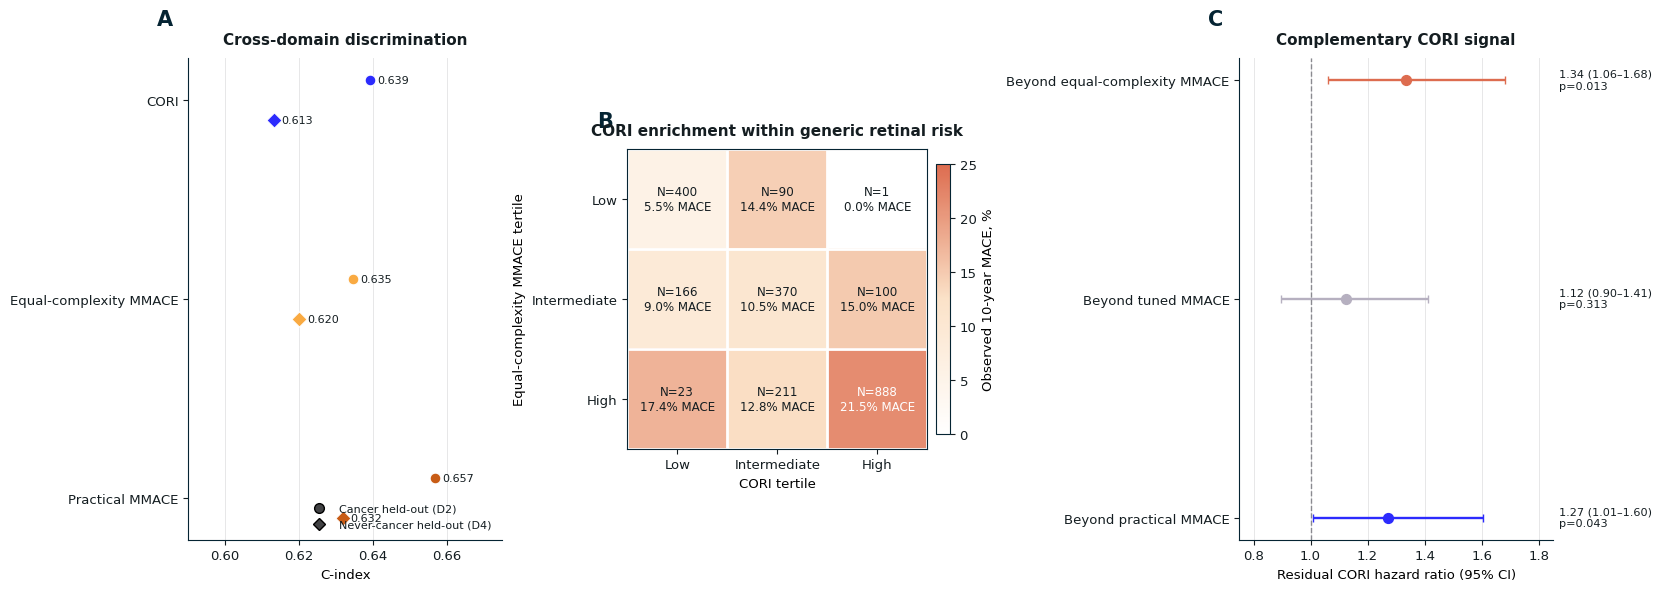

In [6]:

# Figure 3. CORI versus MMACE

fig = plt.figure(figsize=(16.5, 5.8), layout="constrained")
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 1.10, 1.15])

# A. Cross-domain performance
ax_a = fig.add_subplot(gs[0, 0])
model_map = {
    "CORI locked": "CORI",
    "MMACE equal complexity": "Equal-complexity MMACE",
    "MMACE practical": "Practical MMACE",
}
perf = cross_domain[
    cross_domain["cohort"].isin(["D2", "D4"])
    & cross_domain["model"].isin(model_map)
].copy()
perf["label"] = perf["model"].map(model_map)

model_order = ["CORI", "Equal-complexity MMACE", "Practical MMACE"]
model_colors = {"CORI": CORI, "Equal-complexity MMACE": MMACE_MID, "Practical MMACE": MMACE_DARK}
model_y = {label: i for i, label in enumerate(model_order[::-1])}
offset = {"D2": 0.10, "D4": -0.10}
marker = {"D2": "o", "D4": "D"}

for row in perf.itertuples():
    yval = model_y[row.label] + offset[row.cohort]
    ax_a.scatter(row.C_index, yval, s=60, color=model_colors[row.label],
                 marker=marker[row.cohort], edgecolor=WHITE, linewidth=0.8, zorder=3)
    ax_a.text(row.C_index + 0.002, yval, f"{row.C_index:.3f}", va="center", fontsize=8)

ax_a.axvline(0.5, color=GRAY, linestyle="--", linewidth=1)
ax_a.set_yticks(range(3), model_order[::-1])
ax_a.set_xlim(0.59, 0.675)
ax_a.set_xlabel("C-index")
ax_a.set_title("Cross-domain discrimination", pad=10)
clean_axes(ax_a, "x")
legend = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=GRAY_DARK, label="Cancer held-out (D2)", markersize=7),
    Line2D([0], [0], marker="D", color="none", markerfacecolor=GRAY_DARK, label="Never-cancer held-out (D4)", markersize=6),
]
ax_a.legend(handles=legend, frameon=False, loc="lower right", fontsize=8)
panel_letter(ax_a, "A")

# B. Equal MMACE × CORI event-rate matrix
ax_b = fig.add_subplot(gs[0, 1])
order = ["Low", "Middle", "High"]
counts = mmace_counts.set_index("MMACE_equal_tertile").loc[order, order]
rates = mmace_rates.set_index("MMACE_equal_tertile").loc[order, order] * 100
cmap = LinearSegmentedColormap.from_list("event_rate2", [WHITE, MMACE_LIGHT, CORAL])
image = ax_b.imshow(rates.values, cmap=cmap, vmin=0, vmax=max(25, rates.to_numpy().max()))
for i in range(3):
    for j in range(3):
        value = rates.iloc[i, j]
        color = WHITE if value > 18 else BLACK
        ax_b.text(j, i, f"N={int(counts.iloc[i,j]):,}\n{value:.1f}% MACE",
                  ha="center", va="center", fontsize=8.6, color=color)
ax_b.set_xticks(range(3), ["Low", "Intermediate", "High"])
ax_b.set_yticks(range(3), ["Low", "Intermediate", "High"])
ax_b.set_xlabel("CORI tertile")
ax_b.set_ylabel("Equal-complexity MMACE tertile")
ax_b.set_title("CORI enrichment within generic retinal risk", pad=10)
for edge in np.arange(-0.5, 3, 1):
    ax_b.axhline(edge, color=WHITE, linewidth=2)
    ax_b.axvline(edge, color=WHITE, linewidth=2)
colorbar = fig.colorbar(image, ax=ax_b, fraction=0.045, pad=0.03)
colorbar.set_label("Observed 10-year MACE, %")
panel_letter(ax_b, "B")

# C. Residual CORI beyond MMACE
ax_c = fig.add_subplot(gs[0, 2])
residual = residual_results.copy()
residual["label"] = residual["comparator"].replace(
    {
        "Equal-complexity MMACE": "Beyond equal-complexity MMACE",
        "Independently tuned MMACE": "Beyond tuned MMACE",
        "Practical MMACE": "Beyond practical MMACE",
    }
)
residual = residual.iloc[::-1].reset_index(drop=True)
y = np.arange(len(residual))
colors = [CORI, GRAY_MID, CORAL]
for yi, row in enumerate(residual.itertuples()):
    color = colors[yi]
    ax_c.errorbar(
        row.HR, yi,
        xerr=[[row.HR - row.HR_low], [row.HR_high - row.HR]],
        fmt="none", ecolor=color, elinewidth=1.7, capsize=3,
    )
    ax_c.scatter(row.HR, yi, s=50, color=color, zorder=3)
ax_c.axvline(1, color=GRAY, linestyle="--", linewidth=1)
ax_c.set_yticks(y, residual["label"])
ax_c.set_xlim(0.75, 1.85)
ax_c.set_xlabel("Residual CORI hazard ratio (95% CI)")
ax_c.set_title("Complementary CORI signal", pad=10)
clean_axes(ax_c, "x")
for yi, row in enumerate(residual.itertuples()):
    ax_c.text(1.87, yi, f"{row.HR:.2f} ({row.HR_low:.2f}–{row.HR_high:.2f})\n{p_text(row.p)}",
              ha="left", va="center", fontsize=8.1, clip_on=False)
panel_letter(ax_c, "C")

perf.to_csv(SOURCE_DIR / "Figure3_cross_domain_performance.csv", index=False)
mmace_counts.to_csv(SOURCE_DIR / "Figure3_MMACE_CORI_counts.csv", index=False)
mmace_rates.to_csv(SOURCE_DIR / "Figure3_MMACE_CORI_event_rates.csv", index=False)
residual.to_csv(SOURCE_DIR / "Figure3_residual_CORI.csv", index=False)

save_figure(fig, "Figure3_CORI_vs_MMACE")
plt.show()


## Figure 4 — biological anchoring using retinal descriptors and CMR

Saved: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\final_manuscript_figures\Figure4_biological_anchoring.png


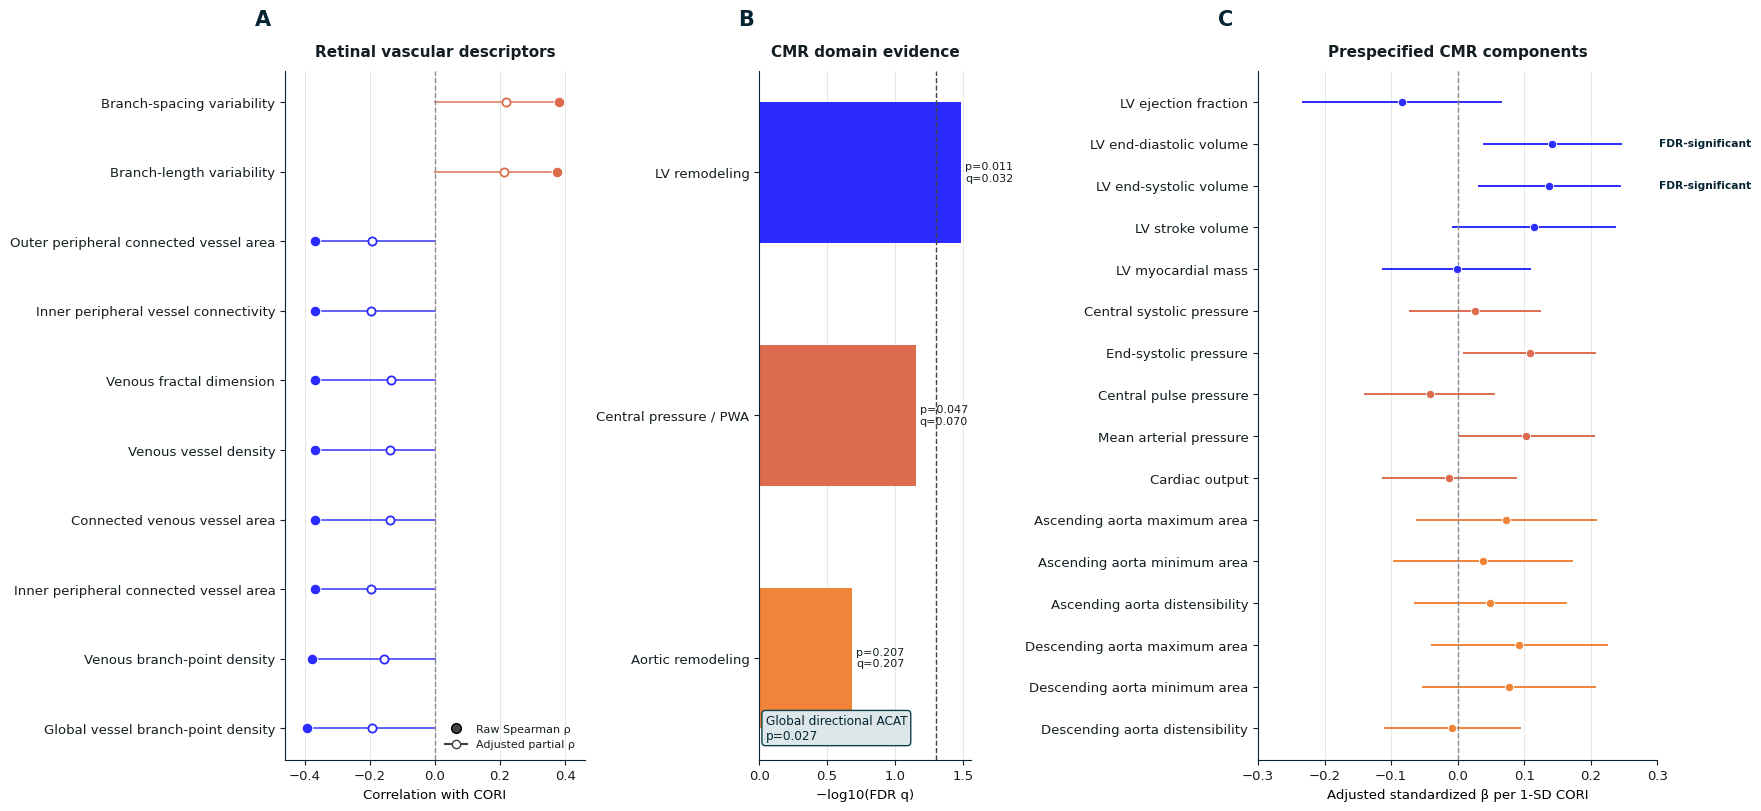

In [7]:

# Figure 4. Biological anchoring

FEATURE_LABELS = {
    "HC_vessel_All_pixel_degree_3": "Global vessel branch-point density",
    "HC_vessel_All_STD_branch_distance": "Branch-spacing variability",
    "HC_vein_All_pixel_degree_3": "Venous branch-point density",
    "HC_vessel_All_STD_branch_length": "Branch-length variability",
    "HC_vessel_fundus_ring_75_125total_connected_pixels": "Inner peripheral connected vessel area",
    "HC_vein_All_total_connected_pixels": "Connected venous vessel area",
    "HC_vein_Allr_VD_binary": "Venous vessel density",
    "HC_vein_Allr_FD_binary": "Venous fractal dimension",
    "HC_vessel_fundus_ring_75_125pixel_degree_2": "Inner peripheral vessel connectivity",
    "HC_vessel_fundus_ring_125_175total_connected_pixels": "Outer peripheral connected vessel area",
}

CMR_LABELS = {
    "LV ejection fraction": "LV ejection fraction",
    "LV end diastolic volume": "LV end-diastolic volume",
    "LV end systolic volume": "LV end-systolic volume",
    "LV stroke volume": "LV stroke volume",
    "LV myocardial mass": "LV myocardial mass",
    "Central systolic blood pressure during PWA - PVR": "Central systolic pressure",
    "End systolic pressure during PWA - PVR": "End-systolic pressure",
    "Central pulse pressure during PWA - PVR": "Central pulse pressure",
    "Mean arterial pressure during PWA - PVR": "Mean arterial pressure",
    "Cardiac output during PWA - PVR": "Cardiac output",
    "Ascending aorta maximum area": "Ascending aorta maximum area",
    "Ascending aorta minimum area": "Ascending aorta minimum area",
    "Ascending aorta distensibility": "Ascending aorta distensibility",
    "Descending aorta maximum area": "Descending aorta maximum area",
    "Descending aorta minimum area": "Descending aorta minimum area",
    "Descending aorta distensibility": "Descending aorta distensibility",
}

fig = plt.figure(figsize=(17.5, 8.0), layout="constrained")
gs = fig.add_gridspec(1, 3, width_ratios=[1.20, 0.85, 1.60])

# A. Retinal descriptors
ax_a = fig.add_subplot(gs[0, 0])
retina = handcrafted.copy()
retina["label"] = retina["feature"].map(FEATURE_LABELS).fillna(retina["feature"])
retina = retina.sort_values("heldout_raw_rho").reset_index(drop=True)
y = np.arange(len(retina))
for yi, row in enumerate(retina.itertuples()):
    color = CORAL if row.heldout_raw_rho > 0 else CORI
    ax_a.plot([0, row.heldout_raw_rho], [yi, yi], color=color, linewidth=1.4, alpha=0.75)
    ax_a.scatter(row.heldout_raw_rho, yi, s=58, color=color, edgecolor=WHITE, linewidth=0.7, zorder=3)
    ax_a.scatter(row.heldout_partial_rho, yi, s=35, facecolor=WHITE, edgecolor=color, linewidth=1.3, zorder=4)
ax_a.axvline(0, color=GRAY, linestyle="--", linewidth=1)
ax_a.set_yticks(y, retina["label"])
ax_a.set_xlim(-0.46, 0.46)
ax_a.set_xlabel("Correlation with CORI")
ax_a.set_title("Retinal vascular descriptors", pad=10)
clean_axes(ax_a, "x")
ax_a.legend(
    handles=[
        Line2D([0], [0], marker="o", color="none", markerfacecolor=GRAY_DARK, label="Raw Spearman ρ", markersize=7),
        Line2D([0], [0], marker="o", color=GRAY_DARK, markerfacecolor=WHITE, label="Adjusted partial ρ", markersize=6),
    ],
    frameon=False, loc="lower right", fontsize=8,
)
panel_letter(ax_a, "A")

# B. CMR domain-level ACAT
ax_b = fig.add_subplot(gs[0, 1])
domains = cmr_domains.copy()
domains["label"] = domains["domain"].replace({"Central pressure / PWA": "Central pressure / PWA"})
domains["minus_log10_q"] = -np.log10(domains["q"])
domain_colors = [CORI, CORAL, MMACE]
bars = ax_b.barh(np.arange(len(domains)), domains["minus_log10_q"], color=domain_colors, height=0.58)
ax_b.axvline(-np.log10(0.05), color=GRAY_DARK, linestyle="--", linewidth=1)
ax_b.set_yticks(np.arange(len(domains)), domains["label"])
ax_b.invert_yaxis()
ax_b.set_xlabel("−log10(FDR q)")
ax_b.set_title("CMR domain evidence", pad=10)
clean_axes(ax_b, "x")
for bar, row in zip(bars, domains.itertuples()):
    ax_b.text(
        bar.get_width() + 0.03,
        bar.get_y() + bar.get_height()/2,
        f"p={row.ACAT_p:.3f}\nq={row.q:.3f}",
        va="center", fontsize=8,
    )
global_p = float(domains["global_directional_ACAT_p"].iloc[0])
ax_b.text(
    0.03, 0.03,
    f"Global directional ACAT\np={global_p:.3f}",
    transform=ax_b.transAxes,
    fontsize=8.7,
    color=NAVY,
    bbox=dict(boxstyle="round,pad=0.3", facecolor=NAVY_LIGHT, edgecolor=NAVY_MID),
)
panel_letter(ax_b, "B")

# C. CMR components
ax_c = fig.add_subplot(gs[0, 2])
cmr = cmr_components.copy()
cmr["label"] = cmr["phenotype"].map(CMR_LABELS).fillna(cmr["phenotype"])
cmr["domain"] = np.select(
    [
        cmr.index < 5,
        (cmr.index >= 5) & (cmr.index < 10),
    ],
    ["LV remodeling", "Central pressure / PWA"],
    default="Aortic remodeling",
)
cmr["color"] = cmr["domain"].map(
    {"LV remodeling": CORI, "Central pressure / PWA": CORAL, "Aortic remodeling": MMACE}
)
cmr = cmr.iloc[::-1].reset_index(drop=True)
y = np.arange(len(cmr))
for yi, row in enumerate(cmr.itertuples()):
    ax_c.plot([row.CI_low, row.CI_high], [yi, yi], color=row.color, linewidth=1.4)
    ax_c.scatter(row.beta, yi, s=36, color=row.color, edgecolor=WHITE, linewidth=0.6, zorder=3)
ax_c.axvline(0, color=GRAY, linestyle="--", linewidth=1)
ax_c.set_yticks(y, cmr["label"])
ax_c.set_xlim(-0.30, 0.30)
ax_c.set_xlabel("Adjusted standardized β per 1-SD CORI")
ax_c.set_title("Prespecified CMR components", pad=10)
clean_axes(ax_c, "x")
for yi, row in enumerate(cmr.itertuples()):
    if row.directional_q_all_phenotypes < 0.05:
        ax_c.text(0.303, yi, "FDR-significant", ha="left", va="center",
                  color=NAVY, fontsize=7.7, fontweight="bold", clip_on=False)
panel_letter(ax_c, "C")

retina.to_csv(SOURCE_DIR / "Figure4_retinal_descriptors.csv", index=False)
domains.to_csv(SOURCE_DIR / "Figure4_CMR_domains.csv", index=False)
cmr.to_csv(SOURCE_DIR / "Figure4_CMR_components.csv", index=False)

save_figure(fig, "Figure4_biological_anchoring")
plt.show()



## Figure 5 — pathway decomposition and cancer-type heterogeneity

The four-way decomposition shown here uses the **current uploaded IPCW output**. Its present adjustment set is age, sex, height, and center. The cancer-type subgroup table currently reflects the covariates available in that completed run.


Saved: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\final_manuscript_figures\Figure5_fourway_and_cancer_subtypes.png


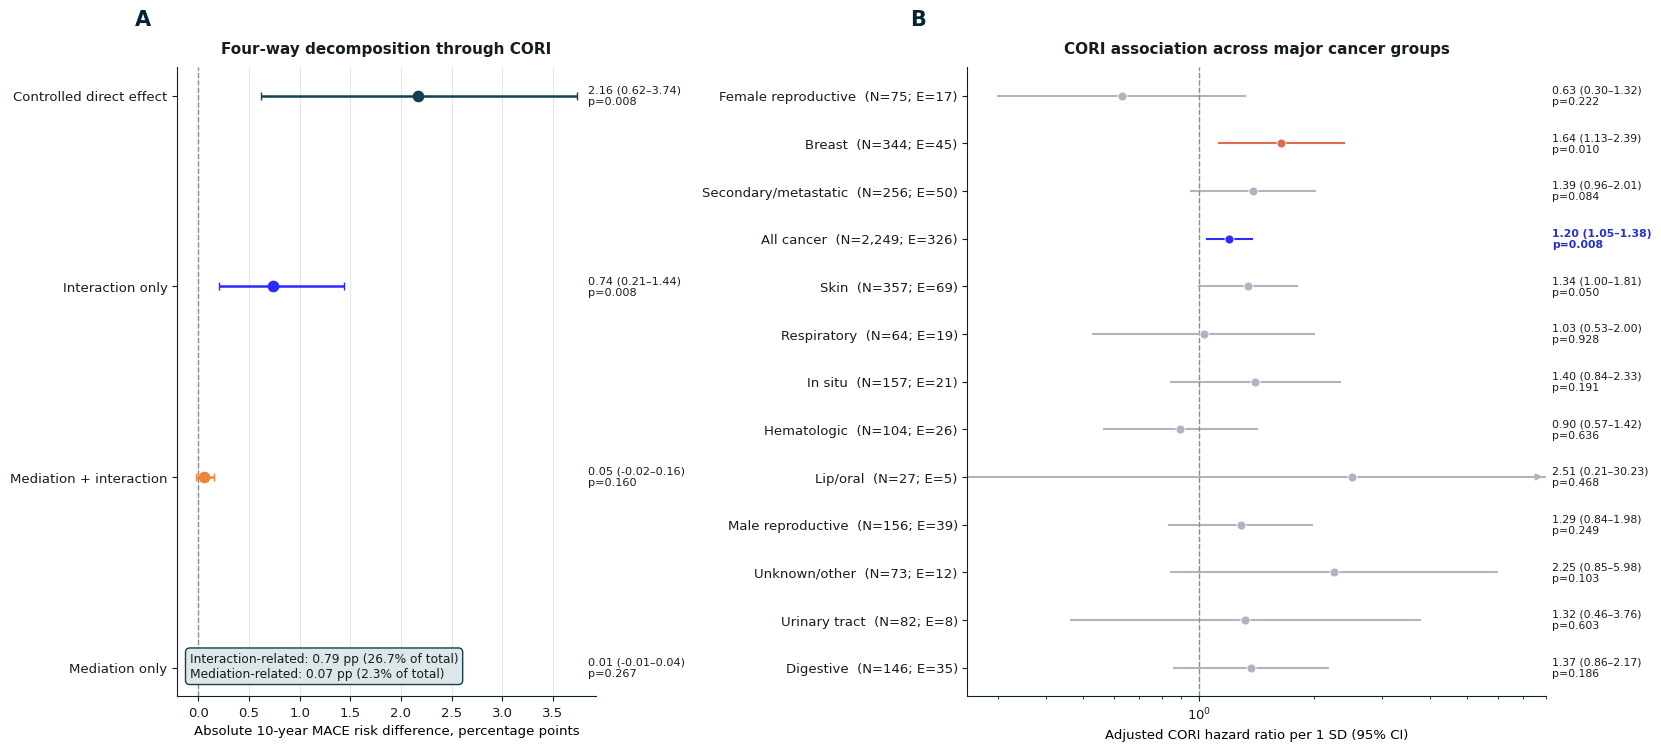

In [8]:

# Figure 5. Four-way decomposition and cancer-type heterogeneity

fig = plt.figure(figsize=(16.5, 7.4), layout="constrained")
gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.45])

# A. Four-way CORI decomposition
ax_a = fig.add_subplot(gs[0, 0])
component_order = ["CDE", "INTref", "INTmed", "PIE"]
component_labels = {
    "CDE": "Controlled direct effect",
    "INTref": "Interaction only",
    "INTmed": "Mediation + interaction",
    "PIE": "Mediation only",
}
component_colors = {"CDE": NAVY_MID, "INTref": CORI, "INTmed": MMACE, "PIE": GRAY_MID}

fw = fourway[fourway["component"].isin(component_order)].copy()
fw["label"] = fw["component"].map(component_labels)
fw["order"] = fw["component"].map({c: i for i, c in enumerate(component_order)})
fw = fw.sort_values("order", ascending=False).reset_index(drop=True)
y = np.arange(len(fw))
colors = fw["component"].map(component_colors).tolist()
for yi, row in enumerate(fw.itertuples()):
    color = component_colors[row.component]
    ax_a.errorbar(
        row.estimate_pp, yi,
        xerr=[[row.estimate_pp - row.ci_low_pp], [row.ci_high_pp - row.estimate_pp]],
        fmt="none", ecolor=color, elinewidth=1.8, capsize=3,
    )
    ax_a.scatter(row.estimate_pp, yi, s=55, color=color, zorder=3)
ax_a.axvline(0, color=GRAY, linestyle="--", linewidth=1)
ax_a.set_yticks(y, fw["label"])
ax_a.set_xlabel("Absolute 10-year MACE risk difference, percentage points")
ax_a.set_title("Four-way decomposition through CORI", pad=10)
clean_axes(ax_a, "x")
for yi, row in enumerate(fw.itertuples()):
    ax_a.text(
        3.85, yi,
        f"{row.estimate_pp:.2f} ({row.ci_low_pp:.2f}–{row.ci_high_pp:.2f})\n{p_text(row.p_value)}",
        ha="left", va="center", fontsize=8.1, clip_on=False,
    )

interaction_total = fourway.loc[fourway["component"] == "interaction_total"].iloc[0]
mediation_total = fourway.loc[fourway["component"] == "mediation_total"].iloc[0]
ax_a.text(
    0.03, 0.03,
    f"Interaction-related: {interaction_total.estimate_pp:.2f} pp "
    f"({100*interaction_total.share_of_TE:.1f}% of total)\n"
    f"Mediation-related: {mediation_total.estimate_pp:.2f} pp "
    f"({100*mediation_total.share_of_TE:.1f}% of total)",
    transform=ax_a.transAxes,
    fontsize=8.8,
    bbox=dict(boxstyle="round,pad=0.35", facecolor=NAVY_LIGHT, edgecolor=NAVY_MID),
)
panel_letter(ax_a, "A")

# B. Cancer-type CORI forest
ax_b = fig.add_subplot(gs[0, 1])
sg = subtypes.copy()
sg["label"] = sg.apply(
    lambda row: f"{row['cancer_type']}  (N={int(row['N']):,}; E={int(row['events'])})",
    axis=1,
)
sg = sg.iloc[::-1].reset_index(drop=True)
y = np.arange(len(sg))
xmax = 8.0
for yi, row in enumerate(sg.itertuples()):
    low = max(row.CORI_CI_low, 0.05)
    high = min(row.CORI_CI_high, xmax)
    color = CORI if row.cancer_type == "All cancer" else (CORAL if row.CORI_p < 0.05 else GRAY_MID)
    ax_b.plot([low, high], [yi, yi], color=color, linewidth=1.5)
    ax_b.scatter(row.CORI_HR_per_SD, yi, s=42, color=color, edgecolor=WHITE, linewidth=0.6, zorder=3)
    if row.CORI_CI_high > xmax:
        ax_b.annotate("", xy=(xmax, yi), xytext=(xmax*0.90, yi),
                      arrowprops=dict(arrowstyle="-|>", color=color, lw=1.3))
ax_b.axvline(1, color=GRAY, linestyle="--", linewidth=1)
ax_b.set_xscale("log")
ax_b.set_xlim(0.25, xmax)
ax_b.set_yticks(y, sg["label"])
ax_b.set_xlabel("Adjusted CORI hazard ratio per 1 SD (95% CI)")
ax_b.set_title("CORI association across major cancer groups", pad=10)
clean_axes(ax_b, "x")
for yi, row in enumerate(sg.itertuples()):
    ax_b.text(
        xmax * 1.04, yi,
        f"{row.CORI_HR_per_SD:.2f} ({row.CORI_CI_low:.2f}–{row.CORI_CI_high:.2f})\n{p_text(row.CORI_p)}",
        ha="left", va="center", fontsize=7.8, clip_on=False,
        color=CORI_DARK if row.cancer_type == "All cancer" else BLACK,
        fontweight="bold" if row.cancer_type == "All cancer" else "normal",
    )
panel_letter(ax_b, "B")

fw.to_csv(SOURCE_DIR / "Figure5_fourway_components.csv", index=False)
sg.to_csv(SOURCE_DIR / "Figure5_cancer_subtypes.csv", index=False)

save_figure(fig, "Figure5_fourway_and_cancer_subtypes")
plt.show()


## Supplementary figures

Saved: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\final_manuscript_figures\Supplementary_Figure1_center_validation.png


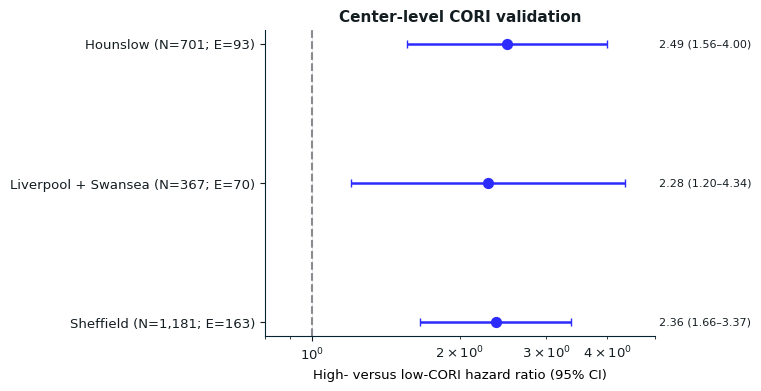

Saved: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\final_manuscript_figures\Supplementary_Figure2_treatment.png


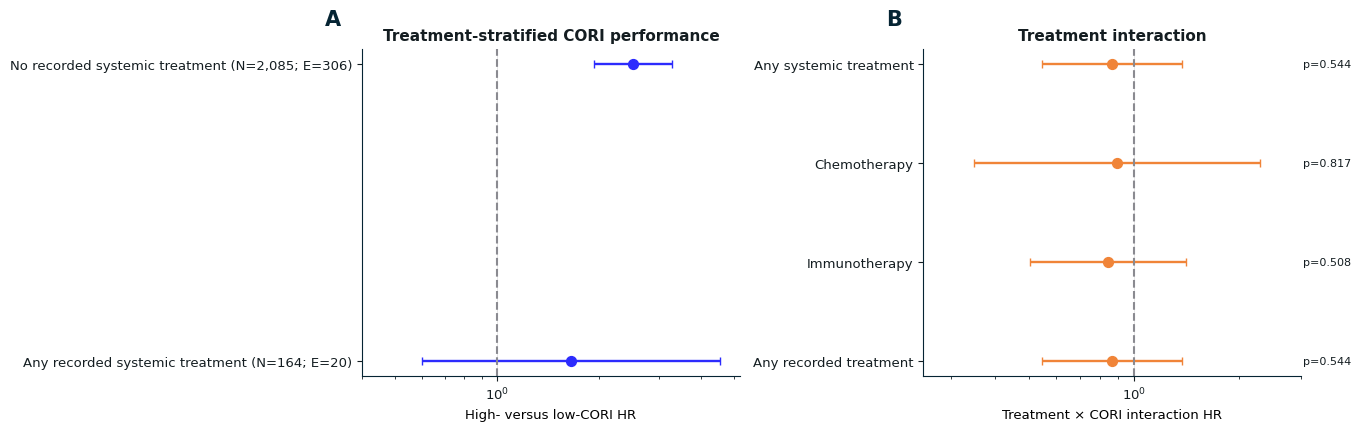

Saved: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\final_manuscript_figures\Supplementary_Figure3_representation_specificity.png


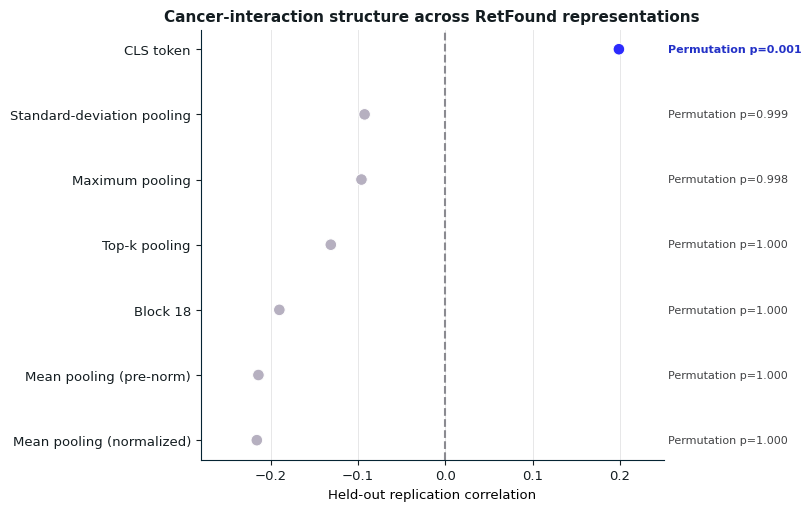

Saved: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\final_manuscript_figures\Supplementary_Figure4_calibration.png


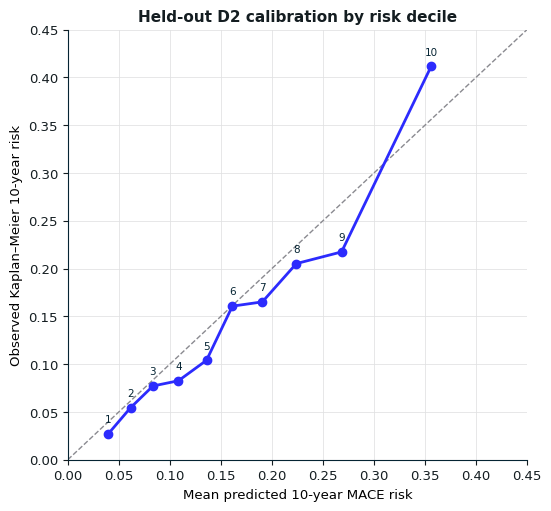

Saved: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\final_manuscript_figures\Supplementary_Figure5_cancer_subtype_Wald_contributions.png


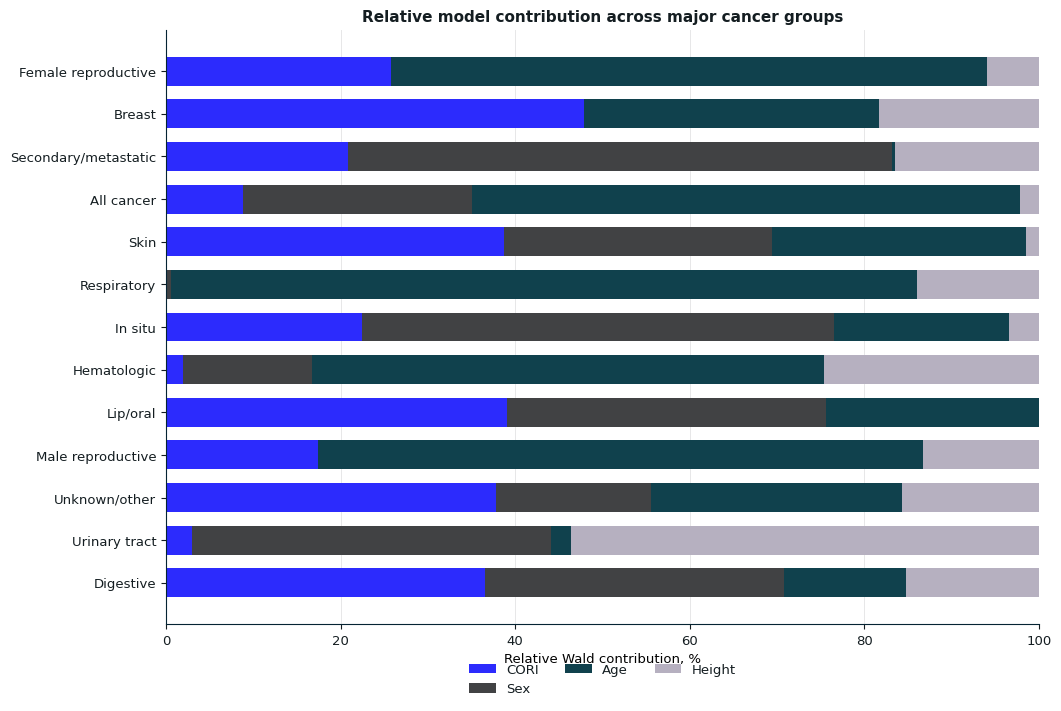

Saved: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\final_manuscript_figures\Supplementary_Figure6_event_horizons.png


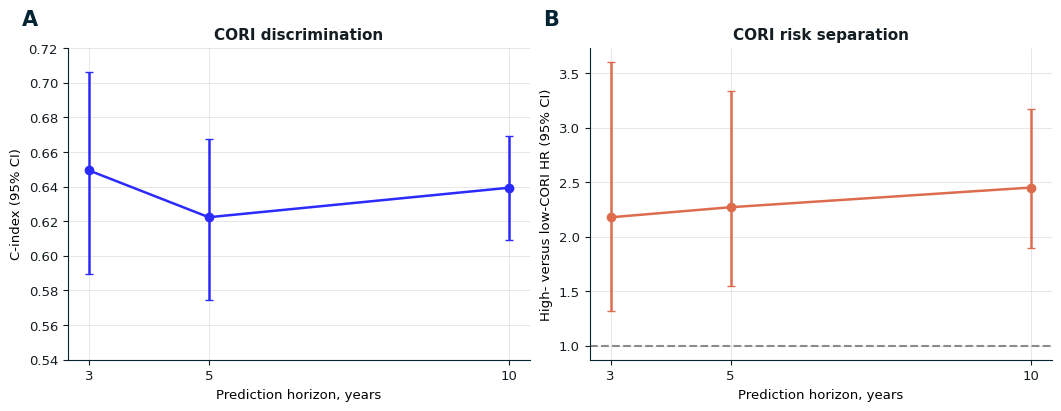

In [9]:

# Supplementary Figure 1. Center-level validation

center = read_csv(TABLE_DIR / "Table_07_center_level_CORI_performance.csv").iloc[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(7.5, 3.8), layout="constrained")
y = np.arange(len(center))
ax.errorbar(
    center["HR"], y,
    xerr=[center["HR"] - center["HR_low"], center["HR_high"] - center["HR"]],
    fmt="none", ecolor=CORI, elinewidth=1.8, capsize=3,
)
ax.scatter(center["HR"], y, color=CORI, s=50, zorder=3)
ax.axvline(1, color=GRAY, linestyle="--")
ax.set_yticks(y, center.apply(lambda r: f"{r['cohort']} (N={int(r['N']):,}; E={int(r['events'])})", axis=1))
ax.set_xscale("log")
ax.set_xlim(0.8, 5.0)
ax.set_xlabel("High- versus low-CORI hazard ratio (95% CI)")
ax.set_title("Center-level CORI validation")
clean_axes(ax, "x")
for yi, row in enumerate(center.itertuples()):
    ax.text(5.1, yi, f"{row.HR:.2f} ({row.HR_low:.2f}–{row.HR_high:.2f})",
            va="center", fontsize=8, clip_on=False)
save_figure(fig, "Supplementary_Figure1_center_validation")
plt.show()


# Supplementary Figure 2. Treatment analyses

treatment_strata = read_csv(TABLE_DIR / "Table_11A_treatment_stratified_CORI.csv")
treatment_interactions = read_csv(TABLE_DIR / "Table_11C_treatment_by_CORI_interactions.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.2), layout="constrained")

ts = treatment_strata.iloc[::-1].reset_index(drop=True)
y = np.arange(len(ts))
ax1.errorbar(ts["HR"], y, xerr=[ts["HR"]-ts["HR_low"], ts["HR_high"]-ts["HR"]],
             fmt="none", ecolor=CORI, capsize=3, elinewidth=1.7)
ax1.scatter(ts["HR"], y, color=CORI, s=50)
ax1.axvline(1, color=GRAY, linestyle="--")
ax1.set_yticks(y, ts.apply(lambda r: f"{r['cohort']} (N={int(r['N']):,}; E={int(r['events'])})", axis=1))
ax1.set_xscale("log")
ax1.set_xlim(0.4, 5.2)
ax1.set_xlabel("High- versus low-CORI HR")
ax1.set_title("Treatment-stratified CORI performance")
clean_axes(ax1, "x")
panel_letter(ax1, "A")

interaction_labels = {
    "has_target_drug": "Any systemic treatment",
    "has_chemo": "Chemotherapy",
    "has_io": "Immunotherapy",
    "any_treatment": "Any recorded treatment",
}
ti = treatment_interactions.copy()
ti["label"] = ti["treatment"].map(interaction_labels).fillna(ti["treatment"])
ti = ti.drop_duplicates("label").iloc[::-1].reset_index(drop=True)
y = np.arange(len(ti))
ax2.errorbar(ti["HR"], y, xerr=[ti["HR"]-ti["HR_low"], ti["HR_high"]-ti["HR"]],
             fmt="none", ecolor=MMACE, capsize=3, elinewidth=1.7)
ax2.scatter(ti["HR"], y, color=MMACE, s=50)
ax2.axvline(1, color=GRAY, linestyle="--")
ax2.set_yticks(y, ti["label"])
ax2.set_xscale("log")
ax2.set_xlim(0.25, 3.0)
ax2.set_xlabel("Treatment × CORI interaction HR")
ax2.set_title("Treatment interaction")
clean_axes(ax2, "x")
for yi, row in enumerate(ti.itertuples()):
    ax2.text(3.05, yi, p_text(row.p), va="center", fontsize=8, clip_on=False)
panel_letter(ax2, "B")

save_figure(fig, "Supplementary_Figure2_treatment")
plt.show()


# Supplementary Figure 3. Representation-specific cancer interaction structure

representation = read_csv(TABLE_DIR / "Table_13_representation_specificity.csv")
representation["label"] = representation["representation"].replace(
    {
        "meanpool_pre": "Mean pooling (pre-norm)",
        "meanpool_norm": "Mean pooling (normalized)",
        "cls": "CLS token",
        "maxpool": "Maximum pooling",
        "blk18": "Block 18",
        "topk10": "Top-k pooling",
        "stdpool": "Standard-deviation pooling",
    }
)
representation = representation.sort_values("heldout_replication_r").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8.0, 5.0), layout="constrained")
y = np.arange(len(representation))
colors = [CORI if rep == "cls" else GRAY_MID for rep in representation["representation"]]
ax.axvline(0, color=GRAY, linestyle="--")
ax.scatter(representation["heldout_replication_r"], y, s=70, c=colors, edgecolor=WHITE, linewidth=0.7)
ax.set_yticks(y, representation["label"])
ax.set_xlim(-0.28, 0.25)
ax.set_xlabel("Held-out replication correlation")
ax.set_title("Cancer-interaction structure across RetFound representations")
clean_axes(ax, "x")
for yi, row in enumerate(representation.itertuples()):
    ax.text(
        0.255, yi,
        f"Permutation p={row.permutation_p:.3f}",
        ha="left", va="center", fontsize=8, clip_on=False,
        color=CORI_DARK if row.representation == "cls" else GRAY_DARK,
        fontweight="bold" if row.representation == "cls" else "normal",
    )
save_figure(fig, "Supplementary_Figure3_representation_specificity")
plt.show()


# Supplementary Figure 4. Calibration

calibration = read_csv(ADDITIONAL_DIR / "Table_9_calibration_deciles.csv")
fig, ax = plt.subplots(figsize=(5.4, 5.0), layout="constrained")
ax.plot([0, 0.45], [0, 0.45], linestyle="--", color=GRAY, linewidth=1)
ax.plot(
    calibration["mean_predicted_risk"],
    calibration["observed_KM_risk"],
    marker="o", markersize=6, linewidth=2, color=CORI,
)
for row in calibration.itertuples():
    ax.text(row.mean_predicted_risk, row.observed_KM_risk + 0.012, str(int(row.decile)),
            ha="center", fontsize=7.5, color=NAVY)
ax.set_xlim(0, 0.45)
ax.set_ylim(0, 0.45)
ax.set_xlabel("Mean predicted 10-year MACE risk")
ax.set_ylabel("Observed Kaplan–Meier 10-year risk")
ax.set_title("Held-out D2 calibration by risk decile")
clean_axes(ax, "both")
save_figure(fig, "Supplementary_Figure4_calibration")
plt.show()


# Supplementary Figure 5. Relative Wald contributions across cancer groups

wald = read_csv(ADDITIONAL_DIR / "Table_15_CORI_subtype_Wald_contributions.csv")
wald["term"] = wald["term"].replace(
    {"CORI_z": "CORI", "age": "Age", "female": "Sex", "height": "Height", "Diabetes": "Diabetes", "HTN": "Hypertension"}
)
order = subtypes["cancer_type"].tolist()
plot_table = (
    wald.pivot_table(index="cancer_type", columns="term", values="relative_wald_percent", aggfunc="sum")
    .fillna(0)
    .reindex(order)
)
column_order = [c for c in ["CORI", "Sex", "Age", "Diabetes", "Hypertension", "Height"] if c in plot_table]
plot_table = plot_table[column_order]

wald_colors = {
    "CORI": CORI,
    "Sex": GRAY_DARK,
    "Age": NAVY_MID,
    "Diabetes": MMACE,
    "Hypertension": CORAL,
    "Height": GRAY_MID,
}

fig, ax = plt.subplots(figsize=(10.5, 7.0), layout="constrained")
left = np.zeros(len(plot_table))
for column in plot_table.columns:
    values = plot_table[column].to_numpy()
    ax.barh(plot_table.index, values, left=left, label=column, color=wald_colors[column], height=0.68)
    left += values
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Relative Wald contribution, %")
ax.set_title("Relative model contribution across major cancer groups")
ax.legend(frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.14))
clean_axes(ax, "x")
save_figure(fig, "Supplementary_Figure5_cancer_subtype_Wald_contributions")
plt.show()


# Supplementary Figure 6. Event-horizon performance

hp = horizon_performance.sort_values("horizon_years")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.0), layout="constrained")

ax1.errorbar(
    hp["horizon_years"], hp["C_index"],
    yerr=[hp["C_index"]-hp["C_low"], hp["C_high"]-hp["C_index"]],
    color=CORI, marker="o", linewidth=1.8, capsize=3,
)
ax1.set_xticks(hp["horizon_years"])
ax1.set_ylim(0.54, 0.72)
ax1.set_xlabel("Prediction horizon, years")
ax1.set_ylabel("C-index (95% CI)")
ax1.set_title("CORI discrimination")
clean_axes(ax1, "both")
panel_letter(ax1, "A")

ax2.errorbar(
    hp["horizon_years"], hp["HR"],
    yerr=[hp["HR"]-hp["HR_low"], hp["HR_high"]-hp["HR"]],
    color=CORAL, marker="o", linewidth=1.8, capsize=3,
)
ax2.axhline(1, color=GRAY, linestyle="--")
ax2.set_xticks(hp["horizon_years"])
ax2.set_xlabel("Prediction horizon, years")
ax2.set_ylabel("High- versus low-CORI HR (95% CI)")
ax2.set_title("CORI risk separation")
clean_axes(ax2, "both")
panel_letter(ax2, "B")

save_figure(fig, "Supplementary_Figure6_event_horizons")
plt.show()


In [10]:

# Final figure manifest

manifest = pd.DataFrame(
    [
        {
            "file": path.name,
            "format": path.suffix.lower().lstrip("."),
            "size_kB": round(path.stat().st_size / 1024, 1),
        }
        for path in sorted(FIGURE_DIR.iterdir())
        if path.is_file() and path.suffix.lower() in {".png", ".pdf", ".svg"}
    ]
)

manifest.to_csv(FIGURE_DIR / "figure_manifest.csv", index=False)
display(manifest)

run_info = {
    "score_representation": "meanpool_pre",
    "D1": {"N": 2009, "events": 290},
    "D2": {"N": 2249, "events": 326},
    "D3": {"N": 14159, "events": 1348},
    "D4": {"N": 14763, "events": 1461},
    "D6": {"N": 611, "events": 56},
    "main_adjusted_Cox_covariates": [
        "age", "sex", "height", "diabetes", "hypertension", "assessment center"
    ],
    "fourway_current_adjustment": [
        "age", "sex", "height", "assessment center"
    ],
}

with open(FIGURE_DIR / "figure_run_info.json", "w", encoding="utf-8") as file:
    json.dump(run_info, file, indent=2)

print("All manuscript figures completed:", FIGURE_DIR)


,file,format,size_kB
0,Central_Illustration_CORI_susceptibility_ampli...,pdf,21.0
1,Central_Illustration_CORI_susceptibility_ampli...,png,553.9
2,Central_Illustration_CORI_susceptibility_ampli...,svg,9.3
3,Figure1_clean_study_design.pdf,pdf,23.4
4,Figure1_clean_study_design.png,png,778.9
5,Figure1_clean_study_design.svg,svg,13.0
6,Figure2_CORI_risk_stratification.pdf,pdf,45.7
7,Figure2_CORI_risk_stratification.png,png,1109.9
8,Figure2_CORI_risk_stratification.svg,svg,109.0
9,Figure3_CORI_vs_MMACE.pdf,pdf,28.4


All manuscript figures completed: F:\CORI_Final\CORI_JACC_Final\CORI_Submit\outputs_refactored\final_manuscript_figures
